In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *

In [2]:
# -----------------------
# 1. DATA
# -----------------------
prices = pd.read_excel('Prices.xlsx', sheet_name='PRICE_ELECTRIC')
p_elec = prices['NP15 ($/MWh)'].tolist()

natural_gas = pd.read_excel('Prices.xlsx', sheet_name='PRICE_GAS')
ng_daily = natural_gas['PG&E Citygate ($/MMBtu)'].tolist()
p_gas = [x for x in ng_daily for _ in range(24)]

co2_cost = 15  # $/MWh

T = range(len(p_elec))

In [3]:
# -----------------------
# PSEUDO-UNIT PARAMETERS
# -----------------------

PU = ['PU1', 'PU2']

params_pu = {
    'PU1': {'min': 150, 'max': 340, 'hr': 6.5, 'vom': 2.5,'startup_cost': 16500, 'startup_fuel': 850, 'min_up': 2, 'min_down': 2},
    'PU2': {'min': 0, 'max': 270, 'hr': 6.3, 'vom': 2.0, 'startup_cost': 7250, 'startup_fuel': 220, 'min_up': 3, 'min_down': 3}
}

# Initial Conditions, everything off
U0 = {'PU1': 0, 'PU2': 0}

In [4]:
# -----------------------
# 2. MODEL
# -----------------------
model = ConcreteModel()

model.T = Set(initialize=T)
model.PU = Set(initialize=PU)


# -----------------------
# 3. VARIABLES
# -----------------------
model.U = Var(model.T, model.PU, domain=Binary)
model.P = Var(model.T, model.PU, domain=NonNegativeReals)
model.SU = Var(model.T, model.PU, domain=Binary)

In [5]:
# -----------------------
# 4. OBJECTIVE
# -----------------------
def obj_rule(model):

    revenue = sum(
        p_elec[t] * (model.P[t,'PU1'] + model.P[t,'PU2'])
        for t in model.T
    )

    op_cost = sum(
        model.P[t,pu] * (
            params_pu[pu]['hr'] * p_gas[t] +
            params_pu[pu]['vom'] +
            co2_cost
        )
        for t in model.T for pu in model.PU
    )

    startup = sum(
        model.SU[t,pu] * (
            params_pu[pu]['startup_cost'] +
            params_pu[pu]['startup_fuel'] * p_gas[t]
        )
        for t in model.T for pu in model.PU
    )

    return revenue - op_cost - startup

model.Profit = Objective(rule=obj_rule, sense=maximize)

In [6]:
# -----------------------
# 5. CONSTRAINTS
# -----------------------

# Power Limits
def p_min_rule(model, t, pu):
    return model.P[t,pu] >= params_pu[pu]['min'] * model.U[t,pu]

def p_max_rule(model, t, pu):
    return model.P[t,pu] <= params_pu[pu]['max'] * model.U[t,pu]

model.PMin = Constraint(model.T, model.PU, rule=p_min_rule)
model.PMax = Constraint(model.T, model.PU, rule=p_max_rule)


# Startup logic 
def startup_rule(model, t, pu):
    if t == 0:
        return model.SU[t,pu] >= model.U[t,pu] - U0[pu]
    return model.SU[t,pu] >= model.U[t,pu] - model.U[t-1,pu]

model.Startup = Constraint(model.T, model.PU, rule=startup_rule)

# Dependency of U2 on U1
def dependency_rule(model, t):
    return model.U[t,'PU2'] <= model.U[t,'PU1']

model.Dependency = Constraint(model.T, rule=dependency_rule)

# Min up time and min down time
def min_up_rule(model, t, pu):
    m_up = params_pu[pu]['min_up']
    if t < m_up:
        return Constraint.Skip
    return sum(model.SU[t-i,pu] for i in range(m_up)) <= model.U[t,pu]

model.MinUp = Constraint(model.T, model.PU, rule=min_up_rule)


def min_down_rule(model, t, pu):
    m_down = params_pu[pu]['min_down']
    if t < m_down:
        return Constraint.Skip
    return sum(model.SU[t-i,pu] for i in range(m_down)) <= 1 - model.U[t-m_down,pu]

model.MinDown = Constraint(model.T, model.PU, rule=min_down_rule) 

In [7]:
# -----------------------
# 6. SOLVE
# -----------------------
solver = SolverFactory('appsi_highs')
results = solver.solve(model)

print(f"Total Profit: ${value(model.Profit):,.2f}")

Total Profit: $127,367.13


In [8]:
# -----------------------
# 7. EXPORT RESULTS (PSEUDO)
# -----------------------
import csv
from datetime import datetime, timedelta

start_date = datetime(2024,1,1)
rows = []

for t in model.T:
    dt = start_date + timedelta(hours=t)

    p1 = value(model.P[t,'PU1'])
    p2 = value(model.P[t,'PU2'])

    rows.append([
        dt.strftime("%Y-%m-%d"),
        dt.hour + 1,
        p_elec[t],
        p_gas[t],
        p1,
        p2
    ])

with open("CCGT_PSEUDO.csv","w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "OPERATING_DATE","HOUR_ENDING",
        "PRICE_ELECTRIC","PRICE_GAS",
        "MW_GENERATION_Unit1",
        "MW_GENERATION_Unit2"
    ])
    writer.writerows(rows)

df = pd.read_csv("CCGT_PSEUDO.csv")
print(df.head(12))

   OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  \
0      2024-01-01            1           45.04       7.05   
1      2024-01-01            2           43.63       7.05   
2      2024-01-01            3           43.43       7.05   
3      2024-01-01            4           43.42       7.05   
4      2024-01-01            5           46.30       7.05   
5      2024-01-01            6           55.50       7.05   
6      2024-01-01            7           76.70       7.05   
7      2024-01-01            8           77.29       7.05   
8      2024-01-01            9           51.19       7.05   
9      2024-01-01           10           46.89       7.05   
10     2024-01-01           11           43.54       7.05   
11     2024-01-01           12           37.18       7.05   

    MW_GENERATION_Unit1  MW_GENERATION_Unit2  
0                   0.0                  0.0  
1                   0.0                  0.0  
2                   0.0                  0.0  
3                 

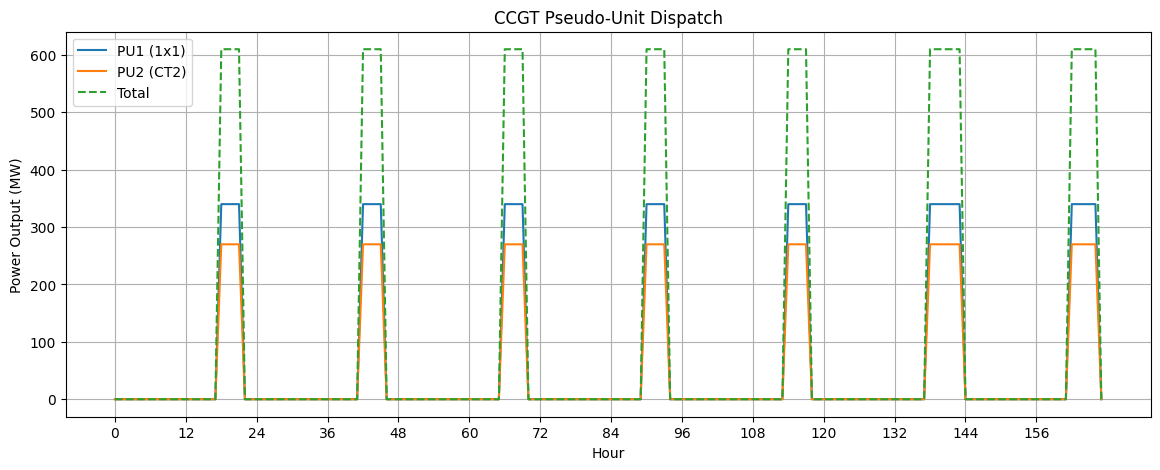

In [9]:
# -----------------------
# 8. PLOTS
# -----------------------
p1_series = [value(model.P[t,'PU1']) for t in model.T]
p2_series = [value(model.P[t,'PU2']) for t in model.T]
total_series = [p1_series[t] + p2_series[t] for t in model.T]

plt.figure(figsize=(14,5))
plt.plot(p1_series, label='PU1 (1x1)')
plt.plot(p2_series, label='PU2 (CT2)')
plt.plot(total_series, linestyle='--', label='Total')

plt.xlabel("Hour")
plt.ylabel("Power Output (MW)")
plt.xticks(range(0, len(p1_series), 12))
plt.title("CCGT Pseudo-Unit Dispatch")
plt.legend()
plt.grid()
plt.show()

In [10]:
def compute_metrics(pu):

    capacity = params_pu[pu]['max']

    # Revenue
    revenue = sum(
        p_elec[t] * value(model.P[t,pu])
        for t in model.T
    )

    # Fuel cost
    fuel_cost = sum(
        value(model.P[t,pu]) * params_pu[pu]['hr'] * p_gas[t]
        for t in model.T
    )

    # VOM
    vom_cost = sum(
        value(model.P[t,pu]) * params_pu[pu]['vom']
        for t in model.T
    )

    # CO2
    co2_total = sum(
        value(model.P[t,pu]) * co2_cost
        for t in model.T
    )

    # Startup
    startup_total = sum(
        value(model.SU[t,pu]) * (
            params_pu[pu]['startup_cost'] +
            params_pu[pu]['startup_fuel'] * p_gas[t]
        )
        for t in model.T
    )

    total_cost = fuel_cost + vom_cost + co2_total + startup_total

    # Generation
    total_mwh = sum(value(model.P[t,pu]) for t in model.T)

    # Capacity factor
    capacity_factor = total_mwh / (capacity * len(model.T))

    # Gross margin ($/kW)
    gross_margin = (revenue - total_cost) / (capacity * 1000)

    # Starts
    starts = sum(value(model.SU[t,pu]) for t in model.T)

    return {
        'Revenue': revenue,
        'Total Cost': total_cost,
        'Fuel Cost': fuel_cost,
        'Capacity Factor': capacity_factor,
        'Gross Margin': gross_margin,
        'Starts': starts
    }

metrics_pu1 = compute_metrics('PU1')
metrics_pu2 = compute_metrics('PU2')

def print_metrics(name, m):
    print(f"\n{name}")
    print(f"Revenue: ${m['Revenue']:,.0f}")
    print(f"Total Cost: ${m['Total Cost']:,.0f}")
    print(f"Fuel Cost: ${m['Fuel Cost']:,.0f}")
    print(f"Capacity Factor: {m['Capacity Factor']*100:.2f}%")
    print(f"Gross Margin: ${m['Gross Margin']:.4f}/kW")
    print(f"Starts: {m['Starts']:.0f}")

print_metrics("PU1", metrics_pu1)
print_metrics("PU2", metrics_pu2)


PU1
Revenue: $857,330
Total Cost: $830,768
Fuel Cost: $488,565
Capacity Factor: 18.45%
Gross Margin: $0.0781/kW
Starts: 7

PU2
Revenue: $680,821
Total Cost: $580,016
Fuel Cost: $376,040
Capacity Factor: 18.45%
Gross Margin: $0.3734/kW
Starts: 7
